# Контрольное сравнение температуры: ERA5 vs станция (2024)

Быстрая проверка согласованности двух источников данных за контрольный год
(раздел 5, пп. 3-4 `PROJECT_BRIEF.md`) — **до** загрузки обоих источников в
единую БД (`db/01_load_to_sqlite.ipynb`).

Сравниваем только температуру воздуха, как самый простой и наглядный
показатель:

- **ERA5** (`ingest/01_era5_ingest.ipynb`) — почасовой реанализ, модельная
  оценка для ближайшего узла сетки (~25 км), без пропусков;
- **Станция** (`ingest/02_station_ingest.ipynb`) — срочные наблюдения раз в
  3 часа непосредственно в Кандалакше.

Если два независимых источника сильно разойдутся (за пределами ожидаемой
разницы "модель vs точечное измерение") — нужно разбираться: ошибка в
единицах измерения, в часовом поясе, в привязке координат и т.п.


In [1]:
# pathlib   - кроссплатформенная работа с путями
# yaml      - чтение config.yaml
# pandas    - таблицы данных
# numpy     - расчёт RMSE
# matplotlib - графики
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

%matplotlib inline


def find_project_root(start: Path) -> Path:
    """Находит корень проекта - каталог, где лежит config.yaml.

    Нужно потому, что рабочий каталог Jupyter зависит от того, как запущен
    ноутбук (из корня проекта или из viz/).
    """
    for parent in [start, *start.parents]:
        if (parent / "config.yaml").exists():
            return parent
    raise FileNotFoundError("Не найден config.yaml - проверьте, откуда запущен ноутбук")


PROJECT_ROOT = find_project_root(Path.cwd())
CONFIG_PATH = PROJECT_ROOT / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

station = config["station"]
period = config["period"]
CLEAN_DIR = PROJECT_ROOT / config["paths"]["clean_dir"]

print(f"Корень проекта: {PROJECT_ROOT}")
print(f"Станция: {station['name']} (ВМО {station['wmo_id']})")
print(f"Период: {period['start_date']} — {period['end_date']}")


Корень проекта: /Users/golochalov/IdeaProjects/Climate analysis
Станция: Кандалакша (ВМО 22217)
Период: 2024-01-01 — 2024-12-31


## Загрузка очищенных данных

Используем результаты ноутбуков `ingest/01_era5_ingest.ipynb` и
`ingest/02_station_ingest.ipynb` — таблицы уже приведены к понятным колонкам
и сохранены в `data/clean/`. Оставляем только `datetime` и температуру.


In [2]:
era5_path = CLEAN_DIR / f"era5_kandalaksha_{period['start_date']}_{period['end_date']}.csv"
station_path = CLEAN_DIR / f"station_kandalaksha_{period['start_date']}_{period['end_date']}.csv"

df_era5 = pd.read_csv(era5_path, parse_dates=["datetime"], usecols=["datetime", "temperature_2m"])
df_station = pd.read_csv(station_path, parse_dates=["datetime"], usecols=["datetime", "temperature"])

print(f"ERA5:    {len(df_era5)} строк, {df_era5['datetime'].min()} — {df_era5['datetime'].max()} (почасово)")
print(f"Станция: {len(df_station)} строк, {df_station['datetime'].min()} — {df_station['datetime'].max()} (раз в 3ч)")


ERA5:    8784 строк, 2024-01-01 00:00:00 — 2024-12-31 23:00:00 (почасово)
Станция: 2928 строк, 2024-01-01 00:00:00 — 2024-12-31 21:00:00 (раз в 3ч)


## Объединение по времени

Срочные наблюдения станции выпадают на 00:00, 03:00, 06:00, ... — то есть
ровно на узлы часовой сетки ERA5. Поэтому объединяем по `datetime` через
`inner join`: должны получить столько же строк, сколько их у станции (2928).
Если строк меньше — значит часть станционных меток времени не попадает на
часовую сетку ERA5 (повод проверить часовой пояс/округление).


In [3]:
df = pd.merge(
    df_station.rename(columns={"temperature": "temp_station"}),
    df_era5.rename(columns={"temperature_2m": "temp_era5"}),
    on="datetime",
    how="inner",
)
df["diff"] = df["temp_station"] - df["temp_era5"]

print(f"Совпавших сроков: {len(df)} из {len(df_station)} станционных")
df.head()


Совпавших сроков: 2928 из 2928 станционных


,datetime,temp_station,temp_era5,diff
0,2024-01-01 00:00:00,-18.1,-19.5,1.4
1,2024-01-01 03:00:00,-16.4,-17.4,1.0
2,2024-01-01 06:00:00,-15.6,-16.5,0.9
3,2024-01-01 09:00:00,-14.2,-15.7,1.5
4,2024-01-01 12:00:00,-14.9,-15.8,0.9


## Сводная статистика расхождений

- **смещение (bias)** — среднее (станция − ERA5): систематическая разница
  между источниками (например, станция в среднем теплее/холоднее модели);
- **MAE** — среднее абсолютное отклонение: типичная величина расхождения
  без учёта знака;
- **RMSE** — среднеквадратичное отклонение: чувствительнее к крупным
  выбросам, чем MAE;
- **корреляция** — насколько синхронно меняются оба ряда (близко к 1 —
  источники "видят" одну и ту же погоду, расходясь лишь в деталях).


In [4]:
bias = df["diff"].mean()
mae = df["diff"].abs().mean()
rmse = np.sqrt((df["diff"] ** 2).mean())
corr = df["temp_station"].corr(df["temp_era5"])

print(f"Систематическое смещение (станция − ERA5), среднее: {bias:+.2f} °C")
print(f"Среднее абсолютное отклонение (MAE):                {mae:.2f} °C")
print(f"Среднеквадратичное отклонение (RMSE):               {rmse:.2f} °C")
print(f"Коэффициент корреляции:                             {corr:.4f}")
print()
print(f"Минимальное расхождение:  {df['diff'].min():+.2f} °C ({df.loc[df['diff'].idxmin(), 'datetime']})")
print(f"Максимальное расхождение: {df['diff'].max():+.2f} °C ({df.loc[df['diff'].idxmax(), 'datetime']})")


Систематическое смещение (станция − ERA5), среднее: -0.58 °C
Среднее абсолютное отклонение (MAE):                1.56 °C
Среднеквадратичное отклонение (RMSE):               2.31 °C
Коэффициент корреляции:                             0.9827

Минимальное расхождение:  -12.30 °C (2024-01-21 12:00:00)
Максимальное расхождение: +5.20 °C (2024-04-17 03:00:00)


## Контрольный график за весь год

Оба ряда на одних осях: ERA5 (почасово, тонкая линия) и станция (раз в
3 часа). Хорошее визуальное совпадение хода температуры — главный признак
того, что оба источника действительно описывают погоду в одном и том же
месте и в одних единицах.


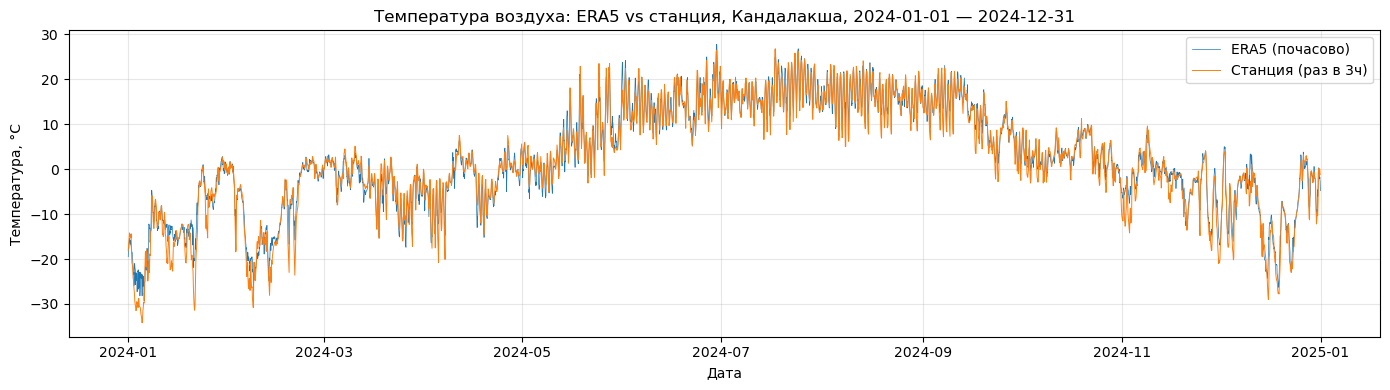

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_era5["datetime"], df_era5["temperature_2m"], linewidth=0.5, color="tab:blue", label="ERA5 (почасово)")
ax.plot(df_station["datetime"], df_station["temperature"], linewidth=0.7, color="tab:orange", label="Станция (раз в 3ч)")
ax.set_title(f"Температура воздуха: ERA5 vs станция, {station['name']}, {period['start_date']} — {period['end_date']}")
ax.set_xlabel("Дата")
ax.set_ylabel("Температура, °C")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Диаграмма рассеяния

Каждая точка — один совпавший срок (станция vs ERA5). Пунктирная линия
`y = x` — идеальное совпадение. Систематическое смещение точек вверх/вниз от
линии соответствует знаку bias выше; разброс вокруг линии — это MAE/RMSE.


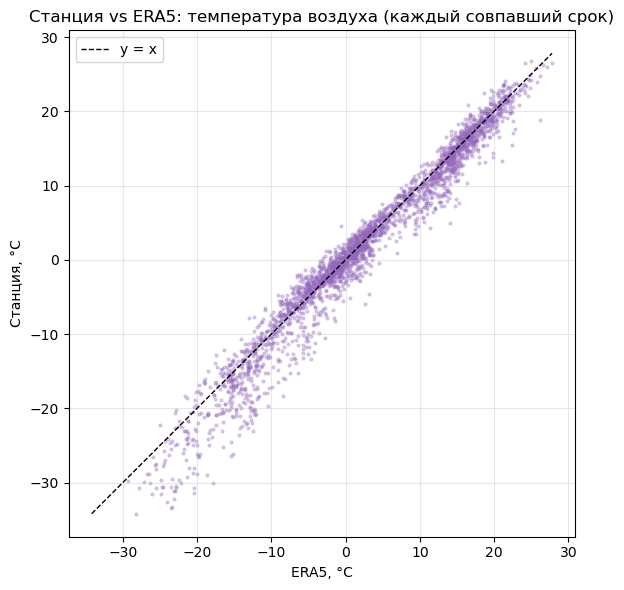

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["temp_era5"], df["temp_station"], s=4, alpha=0.3, color="tab:purple")

lims = [df[["temp_era5", "temp_station"]].min().min(), df[["temp_era5", "temp_station"]].max().max()]
ax.plot(lims, lims, color="black", linewidth=1, linestyle="--", label="y = x")

ax.set_xlabel("ERA5, °C")
ax.set_ylabel("Станция, °C")
ax.set_title("Станция vs ERA5: температура воздуха (каждый совпавший срок)")
ax.set_aspect("equal")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Расхождение по месяцам

Среднее и стандартное отклонение разницы (станция − ERA5) для каждого
месяца — помогает заметить сезонные эффекты (например, более холодные
минимумы у станции зимой из-за снежного покрова и локального выхолаживания,
которые модель с разрешением ~25 км может сглаживать).


In [7]:
monthly = df.groupby(df["datetime"].dt.to_period("M"))["diff"].agg(["mean", "std", "count"])
monthly.columns = ["среднее расхождение, °C", "ст. отклонение, °C", "число сроков"]
monthly


,"среднее расхождение, °C","ст. отклонение, °C",число сроков
datetime,,,
2024-01,-2.100000,3.536026,248
2024-02,-1.080603,2.575797,232
2024-03,0.575000,1.645833,248
2024-04,0.312917,1.691116,240
2024-05,-0.013710,2.057821,248
2024-06,-0.612500,1.597307,240
2024-07,-0.424597,1.424852,248
2024-08,-0.434677,1.893289,248
2024-09,-0.947917,1.719272,240


## Итог

- Станционные сроки (раз в 3 часа) полностью совпали с узлами часовой сетки
  ERA5 — объединение по `datetime` прошло без потерь.
- Числовые показатели расхождения (bias, MAE, RMSE, корреляция) и графики
  выше — основа для методической заметки в журнал решений (раздел 6 брифа):
  ожидаемая разница "модель vs точечное измерение" против признаков
  реальной проблемы (смещение часового пояса, единиц измерения и т.п.).
- Это сравнение — только по температуре и только проверка согласованности
  источников. Полное сведение всех переменных обоих источников в единую БД
  по схеме `weather_data` — следующий шаг, `db/01_load_to_sqlite.ipynb`.
